# Mackenzie River Outflow SSS and day of sea ice formation

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
from scipy.stats import t
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:42883")
client

<Client: 'tcp://127.0.0.1:42883' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
SALT_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

# open RHOAnoma zarr store - [fraction of sea ice, 0 to 1]
RHOAnoma_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/RHOAnoma_AVG_DAILY.ZARR/', s3_options)

In [7]:
# remove 2021 since we only have January and a few days in Feb that year
salt_day = SALT_zarr_day.SALT.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
theta_day = THETA_zarr_day.THETA.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
ice_day = SI_zarr_day.SIarea.sel(time=slice("2014","2020")).where(HH_grid.mask_basin.isel(k=0)==1)*100 # convert to percentage

# add reference density to density anomaly (RHOAnoma)
rhoConst = 1027.5 # reference density
density_day = RHOAnoma_zarr_day.RHOAnoma.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1) + rhoConst

In [8]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

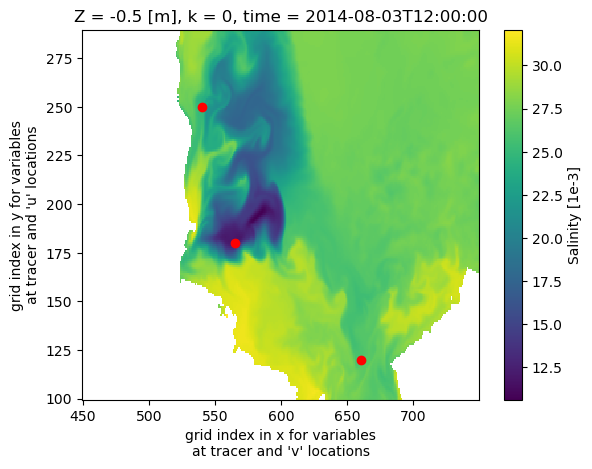

In [9]:
# plot Beaufort Sea area
salt_day.isel(k=0,i=slice(450,750),j=slice(100,290),time=200).plot();
plt.scatter(565,180,c='r');
plt.scatter(540,250,c='r');
plt.scatter(660,120,c='r');

#### Calculate MLD using $\Delta\rho$

In [163]:
# select one grid cell and date range
# density_select = density_day.isel(i=565,j=180).sel(time=slice("2019-09","2019-11"))
density_select = density_day.isel(i=565,j=180).sel(time=slice("2019-06","2019-12"))

In [164]:
rho_surf = density_select.isel(k=2) # take near surface grid cell (Z=2.79 m)
rho_surf = density_select.isel(k=0) # take near surface grid cell (Z=0.5 m)

In [165]:
# add threshold
density_threshold = 0.1 # kg m^-3
# density_threshold = 0.4 # kg m^-3
# density_threshold = 0.03 # kg m^-3
threshold = (rho_surf + density_threshold)

In [166]:
# subtract threshold from density profiles
density_minus_threshold = abs(density_select-threshold)

In [167]:
# identify index for where density exceeds threshold
threshold_idx = density_minus_threshold.argmin(dim='k',skipna=True)
# threshold_idx = density_minus_threshold.argmin(dim='k',skipna=True) + 1

In [168]:
# extract depth where density exceeds threshold (=MLD)
MLD_profiles = density_select.isel(k=threshold_idx.compute()).Z

Explore KPP variable to double check

In [114]:
# look at KPP to validate surface mixing
# open KPPhbl zarr store - [meters]
KPPdiffS_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/KPPdiffS_AVG_DAILY.ZARR/', s3_options)
KPPdiffS = KPPdiffS_zarr.KPPdiffS

In [144]:
kpp_day = KPPdiffS.isel(i=565,j=180).sel(time=slice("2019-06","2019-12"))

In [162]:
KPPdiffS.Z.values[0:2]

array([-0.5 , -1.57], dtype=float32)

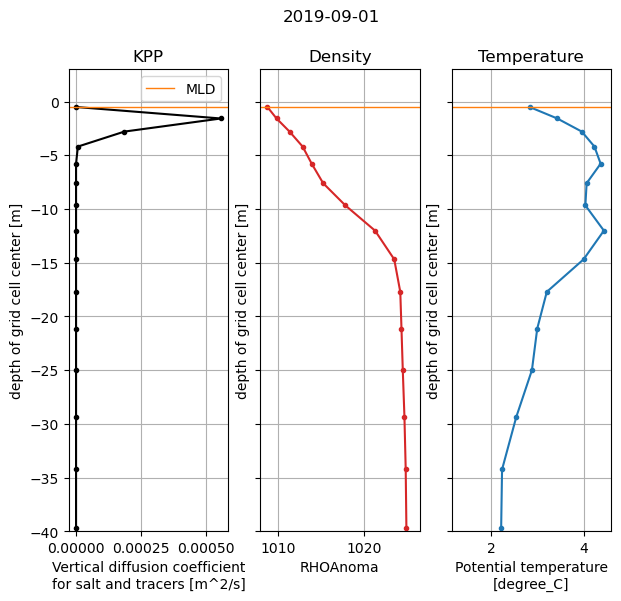

In [169]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=[7, 6])

date = '2019-09-01'
MLD = MLD_profiles.sel(time=date).values
kpp_day.sel(time=date).plot(ax=ax1,y='Z',marker='.',color='k')
ax1.set_ylim(-40,3);
density_day.isel(i=565,j=180).sel(time=date).plot(y='Z',ax=ax2,marker='.',color='tab:red');
theta_day.isel(i=565,j=180).sel(time=date).plot(y='Z',ax=ax3,marker='.',color='tab:blue');

ax1.set_title("KPP")
ax2.set_title("Density")
ax3.set_title("Temperature")

plt.suptitle(date)

for ax in (ax1,ax2,ax3):
    ax.grid()
    ax.axhline(y=MLD, linewidth=1, color='tab:orange',label='MLD')

ax1.legend();

In [182]:
def plot_profiles(date1, date2, theta_day, salt_day, density_day, MLD_profiles, i=565, j=180):
    """
    Plots temperature and salinity profiles for two different dates.

    Parameters:
    - date1, date2: Dates to plot (must be strings in 'YYYY-MM-DD' format).
    - theta_day: Dataset containing temperature values.
    - salt_day: Dataset containing salinity values.
    - MLD_profiles: Dataset containing Mixed Layer Depth (MLD) values.
    - i, j: Grid indices to extract data from (default: 565, 180).
    """
    
    # Create figure and subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=[6, 6])

    # Add a title to the whole figure
    fig.suptitle(f"SASSIE ECCO grid cell [i={i}, j={j}]", fontsize=14)

    # Plot first date (dashed line)
    theta1 = theta_day.isel(i=i, j=j).sel(time=date1)
    salt1 = salt_day.isel(i=i, j=j).sel(time=date1)

    # MLD
    density_select = density_day.isel(i=i, j=j).sel(time=slice(date1,date2))
    rho_surf = density_select.isel(k=0) # take near surface grid cell (Z=0.5 m)
    density_threshold = 0.1 # kg m^-3
    threshold = (rho_surf + density_threshold)
    density_minus_threshold = abs(density_select-threshold)
    # identify index for where density exceeds threshold
    threshold_idx = density_minus_threshold.argmin(dim='k',skipna=True)
    # extract depth where density exceeds threshold (=MLD)
    MLD_profiles = density_select.isel(k=threshold_idx.compute()).Z
    
    MLD1 = MLD_profiles.sel(time=date1).values.item()  # Ensure scalar

    theta1.plot(ax=ax1, y='Z', color='tab:blue', marker='.', linestyle='dashed', label=f"{date1}")
    salt1.plot(ax=ax2, y='Z', color='tab:red', marker='.', linestyle='dashed')

    ax1.axhline(y=MLD1, linewidth=1, color='tab:orange', linestyle='dashed', label="MLD (date1)")
    ax2.axhline(y=MLD1, linewidth=1, color='tab:orange', linestyle='dashed')

    # Plot second date (solid line)
    theta2 = theta_day.isel(i=i, j=j).sel(time=date2)
    salt2 = salt_day.isel(i=i, j=j).sel(time=date2)
    MLD2 = MLD_profiles.sel(time=date2).values.item()

    theta2.plot(ax=ax1, y='Z', color='tab:blue', label=f"{date2}")
    salt2.plot(ax=ax2, y='Z', color='tab:red')

    ax1.axhline(y=MLD2, linewidth=1, color='tab:orange', label="MLD (date2)")
    ax2.axhline(y=MLD2, linewidth=1, color='tab:orange')

    # Formatting axes
    for ax in (ax1, ax2):
        # ax.set_ylim(-40, 3)
        ax.set_ylim(-60, 3)
        ax.axhline(y=0, c='k', linewidth=0.5, linestyle='dashed')
        # ax.axhline(y=-15, linewidth=1, color='gray')  # Example reference line
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.set_title("")

    # ax1.set_xlim(-2, 6.5)
    # ax2.set_xlim(0, 33)

    ax1.set_ylabel("Depth (m)")
    ax1.set_xlabel("Temperature ($\degree$C)")
    ax2.set_xlabel("Salinity (g/kg)")

    # Add legend
    ax1.legend(loc='lower left')

    # Show the plot
    plt.show()

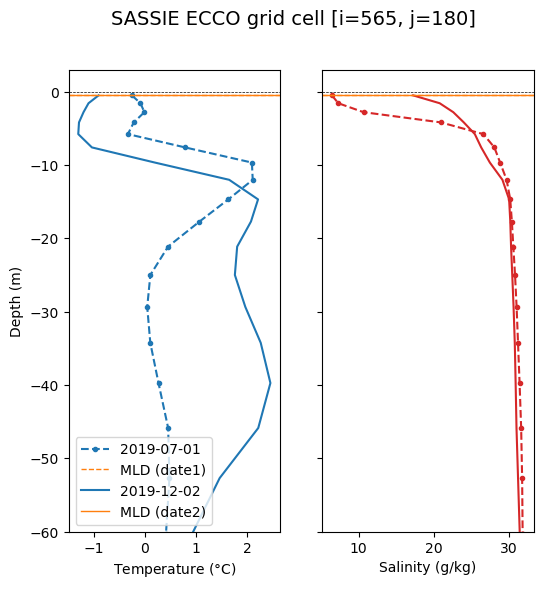

In [183]:
plot_profiles("2019-07-01", "2019-12-02", theta_day, salt_day, density_day, MLD_profiles)

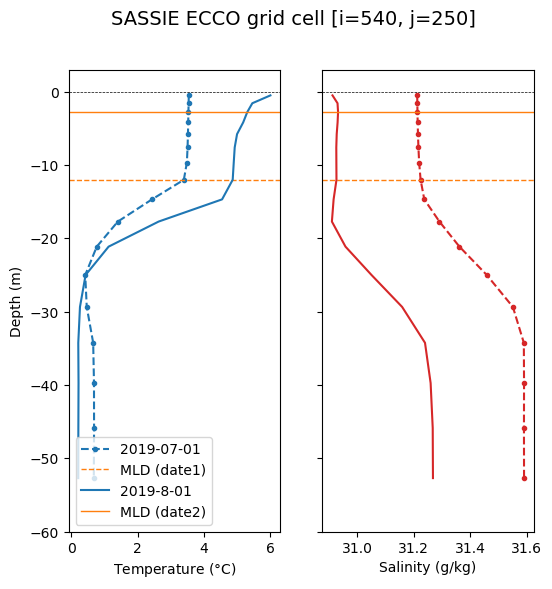

In [185]:
plot_profiles("2019-07-01", "2019-8-01", theta_day, salt_day, density_day, MLD_profiles, i=540, j=250)

In [256]:
def plot_profile(date, theta_day, salt_day, density_day, i=565, j=180):
    """
    Plots temperature and salinity profiles for a single date with solid lines,
    with salinity as a secondary axis on the temperature plot, and density on a separate axis.

    Parameters:
    - date: Date to plot (must be a string in 'YYYY-MM-DD' format).
    - theta_day: Dataset containing temperature values.
    - salt_day: Dataset containing salinity values.
    - density_day: Dataset containing density values.
    - i, j: Grid indices to extract data from (default: 565, 180).
    """
    
    # Create figure and subplots
    plt.rcParams['font.size'] = 14
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[6, 6], sharey=True)

    # Extract data for the given date
    theta = theta_day.isel(i=i, j=j).sel(time=date)
    salt = salt_day.isel(i=i, j=j).sel(time=date)
    density = density_day.isel(i=i, j=j).sel(time=date)
    
    # Compute MLD
    density_select = density_day.isel(i=i, j=j).sel(time=date)
    rho_surf = density_select.isel(k=0)  # Near-surface density
    density_threshold = 0.1  # kg m^-3
    threshold = rho_surf + density_threshold
    density_minus_threshold = abs(density_select - threshold)
    threshold_idx = density_minus_threshold.argmin(dim='k', skipna=True)
    MLD = density_select.isel(k=threshold_idx.compute()).Z.values.item()
    
    # Plot temperature profile
    theta.plot(ax=ax1, y='Z', color='tab:blue', marker='.', linestyle='solid')
    ax1.axhline(y=MLD, linewidth=1, color='tab:orange', linestyle='solid', label="MLD")
    ax1.tick_params(axis='x', colors='tab:blue')
    
    # Add salinity profile as a secondary axis
    ax1_sec = ax1.twiny()
    salt.plot(ax=ax1_sec, y='Z', color='tab:red', marker='.', linestyle='solid')
    ax1_sec.tick_params(axis='x', colors='tab:red')
    
    # Plot density profile
    density.sel(k=slice(0,18)).plot(ax=ax2, y='Z', color='black', marker='.', linestyle='solid')
    ax2.axhline(y=MLD, linewidth=1, color='tab:orange', linestyle='solid')
    ax2.set_ylabel("")
    
    # Formatting axes
    for ax in (ax1, ax1_sec, ax2):
        ax.set_ylim(-60, 3)
        ax.axhline(y=0, c='k', linewidth=0.5, linestyle='dashed')
        ax.set_title("")
    
    # Add legend
    ax1.legend(loc='lower left')

    # Add labels
    ax1.set_xlabel("Temp ($\degree$C)", color='tab:blue')
    ax1_sec.set_xlabel("Salinity (g/kg)", color='tab:red')
    ax1.set_ylabel("Depth (m)")
    ax2.set_xlabel("Density (kg/m³)")

    # Add a title to the whole figure
    fig.suptitle(f"Grid cell [i={i}, j={j}]\n{date}", fontsize=14, y=1.05)
    
    # Show the plot
    plt.show()

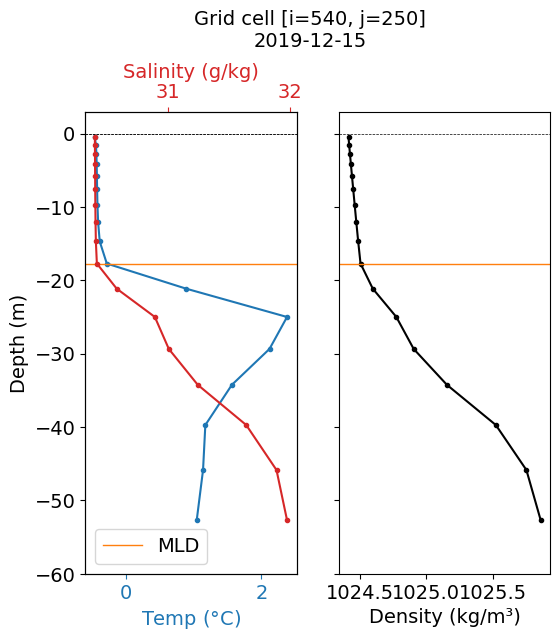

In [267]:
plot_profile("2019-12-15", theta_day, salt_day, density_day, i=540, j=250)

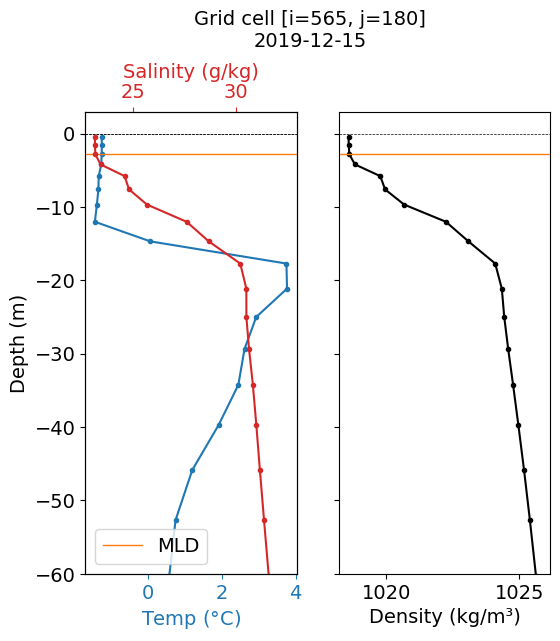

In [268]:
plot_profile("2019-12-15", theta_day, salt_day, density_day, i=565, j=180)

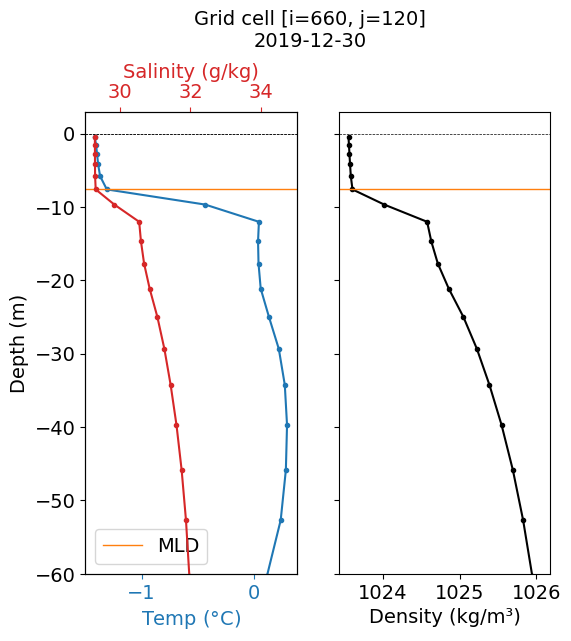

In [270]:
plot_profile("2019-12-30", theta_day, salt_day, density_day, i=660, j=120)

### Animation

In [39]:
from matplotlib import animation

MovieWriter Pillow unavailable; using Pillow instead.


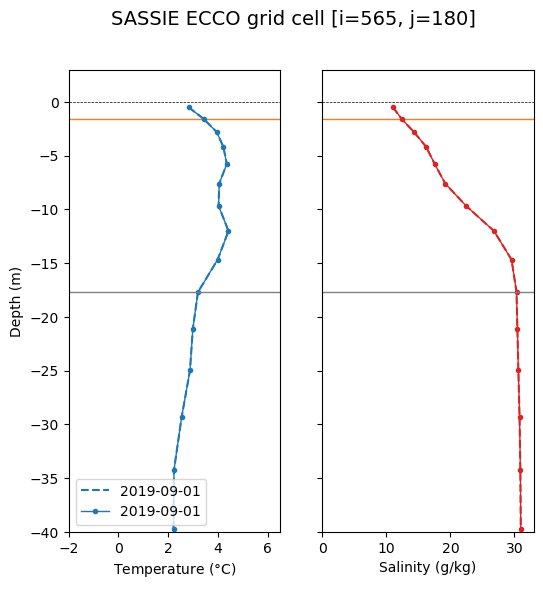

In [44]:
# Define start and end dates
dates = np.arange(np.datetime64('2019-09-01'), np.datetime64('2019-09-02') + np.timedelta64(1, 'D'))

# Create figure and subplots (now only 2 panels)
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=[6, 6])  # Adjusted figsize

# Add a title to the whole figure
fig.suptitle("SASSIE ECCO grid cell [i=565, j=180]", fontsize=14)

# Plot initial reference profile (dashed line)
initial_date = str(dates[0])
theta_day.isel(i=565, j=180).sel(time=initial_date).plot(ax=ax1, y='Z', color='tab:blue', linestyle='dashed', label=initial_date)
salt_day.isel(i=565, j=180).sel(time=initial_date).plot(ax=ax2, y='Z', color='tab:red', linestyle='dashed')

# Pull out initial MLD
MLD = MLD_profiles.sel(time=initial_date).values.item()  # Ensure scalar value
line3a = ax1.axhline(y=MLD, linewidth=1, color='tab:orange')
line3b = ax2.axhline(y=MLD, linewidth=1, color='tab:orange')

# Initialize empty lines for animation
line1, = ax1.plot([], [], color='tab:blue', label='', marker='.', linewidth=1)
line2, = ax2.plot([], [], color='tab:red', marker='.', linewidth=1)

def update(frame):
    current_date = str(dates[frame])
    
    # Update solid-line profiles for the current date
    theta = theta_day.isel(i=565, j=180).sel(time=current_date)
    salt = salt_day.isel(i=565, j=180).sel(time=current_date)

    # Pull out MLD and ensure it's a scalar
    MLD = MLD_profiles.sel(time=current_date).values.item()
    
    line1.set_data(theta, theta['Z'])
    line1.set_label(current_date)
    line2.set_data(salt, salt['Z'])

    # Update MLD lines
    line3a.set_ydata([MLD, MLD])
    line3b.set_ydata([MLD, MLD])

    ax1.legend(loc='lower left')
    return line1, line2, line3a, line3b

# Formatting axes
for ax in (ax1, ax2):
    ax.set_ylim(-40, 3)
    ax.axhline(y=0, c='k', linewidth=0.5, linestyle='dashed')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("")
    ax.axhline(y=salt_day.isel(k=9).Z.values, linewidth=1, color='gray')

ax1.set_xlim(-2, 6.5)
ax2.set_xlim(0, 33)

ax1.set_ylabel("Depth (m)")
ax1.set_xlabel("Temperature ($\degree$C)")
ax2.set_xlabel("Salinity (g/kg)")

# Run animation
ani = animation.FuncAnimation(fig, update, frames=len(dates), interval=500, blit=False)

# Save animation as MP4
ani.save('profile_animation_tmp.gif', writer='Pillow', fps=6)
# ani.save('profile_animation_plume.mp4', writer='ffmpeg', fps=6)